# Import libraries

In [139]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [140]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [141]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def Friedmann_eq2(z, theta):
    omega_k, omega_DE, H0, w = theta
    omega_M = 1 - omega_k - omega_DE
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k, omega_DE, H0, w = theta
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    if not np.all(dl>0):
        print(f"luminosity distance isn't positive, {dl}, {s_k}, {rc}, {theta}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

In [142]:
#different equations of state:

"""w = w0 #wCDM
w = w0 + wa*(1+z)"""


'w = w0 #wCDM\nw = w0 + wa*(1+z)'

# Load the data

In [143]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [144]:
def log_prior(theta, z):
    omega_k, omega_DE, H0, w = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-0.05<omega_k<0.05 and np.all(H2>0) and -2<w<0 and H0>0):
        return -np.inf
    return -0.5*(omega_DE-0.666)**2/0.018**2-0.5*(H0-73.5)**2/1.1**2

nparams = 4
nwalkers = 32
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.6, 0.75)
    pos[i][2] = np.random.uniform(60, 80)
    pos[i][3] = np.random.uniform(-1,-0.5)
    

# Likelihood function

In [145]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [146]:
nsteps = 5000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 5000/5000 [07:48<00:00, 10.67it/s]


State([[-1.97256035e-02  6.65725492e-01  7.12599773e+01 -9.41418486e-01]
 [ 7.52473471e-03  6.88529708e-01  7.30185914e+01 -7.93230641e-01]
 [ 3.05215847e-02  7.20713691e-01  7.50786577e+01 -7.60749049e-01]
 [ 8.77741070e-03  6.61038551e-01  7.27847950e+01 -8.21723205e-01]
 [ 9.08859711e-03  6.88909931e-01  7.37957290e+01 -9.12732099e-01]
 [ 1.26952463e-02  6.60441789e-01  7.33150824e+01 -8.50912626e-01]
 [ 1.44182051e-02  6.92430043e-01  7.37993118e+01 -8.37825547e-01]
 [ 5.90900907e-03  6.69390218e-01  7.30325789e+01 -8.58944691e-01]
 [ 2.49790178e-02  6.65563429e-01  7.47201888e+01 -8.90879497e-01]
 [ 1.94923601e-02  6.82844288e-01  7.43318818e+01 -9.06082267e-01]
 [ 2.17835736e-02  6.90749572e-01  7.45384716e+01 -8.41247188e-01]
 [ 1.99538669e-02  6.59593004e-01  7.40484270e+01 -8.70455697e-01]
 [ 2.66637300e-02  6.69343650e-01  7.45631322e+01 -8.58225301e-01]
 [ 6.18792897e-03  6.39208784e-01  7.28414249e+01 -9.13131366e-01]
 [ 1.16671267e-02  6.75004174e-01  7.32755732e+01 -8.621

autocorrelation time is [44.73272509 44.86629894 43.46927248 41.79741928]


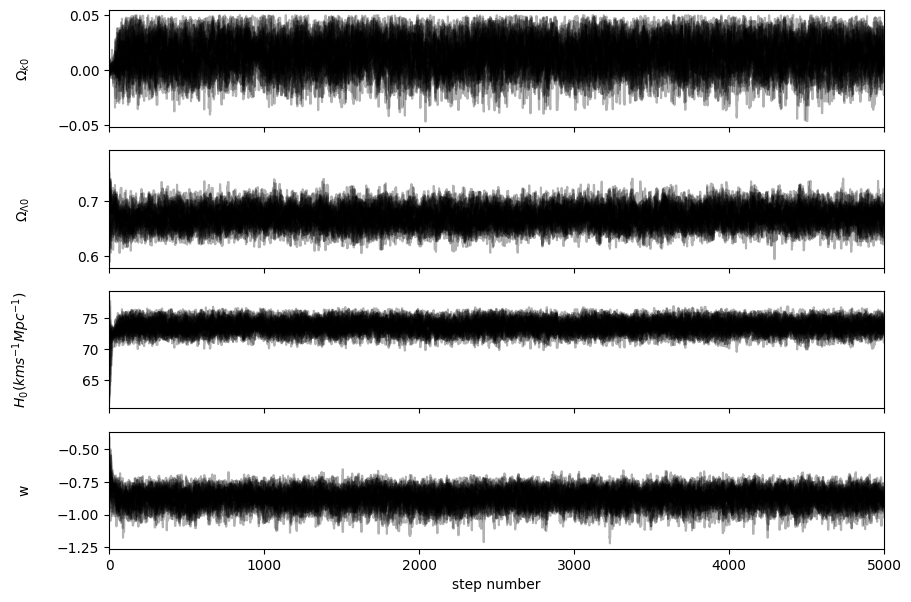

In [147]:
ndiscard = 100 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{Λ0}$", "$H_{0} (kms^{-1}Mpc^{-1})$", "w"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers2.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

# Covariance plots

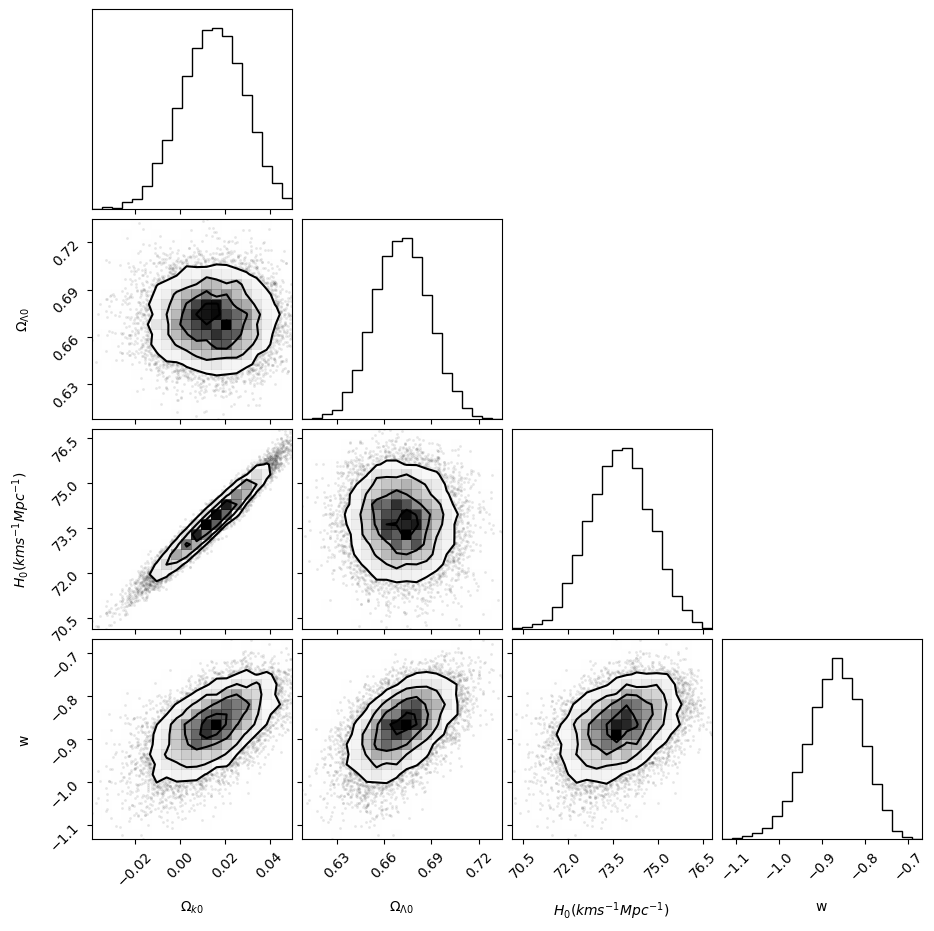

In [148]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner.png")

In [149]:
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[1]}")

$Ω_{k0}$: 0.014563898592386606 + 0.013999951424567251 - 0.013999951424567251
$Ω_{Λ0}$: 0.6709576300454907 + 0.017458052661660006 - 0.017458052661660006
$H_{0} (kms^{-1}Mpc^{-1})$: 73.72073059029235 + 1.036641752526208 - 1.036641752526208
w: -0.8684678375935249 + 0.05969394914040549 - 0.05969394914040549


In [150]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])

C:\Users\milan\AppData\Local\Temp\ipykernel_15024\959742737.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta_model[i] = np.percentile(flat_samples[:, i], [50])


chi-squared: 1749.9615095548306


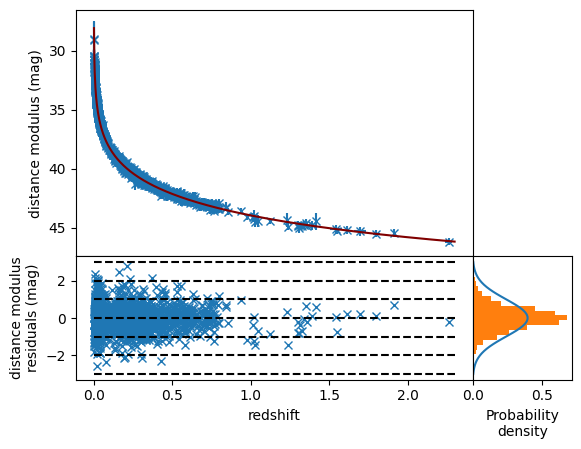

In [151]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
axs[0,0].invert_yaxis()
#axs[0,0].set_xscale("log")
#axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 24))
plt.show()